**Laboratorio 5: clasificacion Multiclase**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: sensores de gases**


**IMPORTACION DE LIBRERIAS Y HERRAMIENTAS**

bueno para empezar lo que hacemos aca es traer todas las herramientas que necesitamos para el laboratorio primero llamamos a pytorch que es el corazon de nuestra red neuronal y tambien a numpy para manejar los datos numericos usamos sklearn para cosas clave como cargar los archivos dat que son especiales y para escalar los datos porque los sensores quimicos necesitan estar bien nivelados tambien metemos librerias para hacer las graficas bonitas y ver como va aprendiendo la ia paso a paso con las barras de carga y las herramientas de evaluacion final que nos diran que tan bien reconoce cada gas el modelo de fusion que vamos a construir de aqui en adelante

In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**CARGA Y PREPROCESAMIENTO DE LOS DATOS QUIMICOS**

aca lo primero que hacemos es marcarle el camino a la computadora para que encuentre la carpeta con los diez archivos de los gases en tu drive personal de ahi revisamos que la carpeta exista de verdad para no tener errores y empezamos a leer archivo por archivo usando una funcion especial que entiende ese formato dat tan raro que tienen estos sensores quimicos despues de leerlos todos los pegamos uno encima del otro para tener una sola matriz gigante con toda la informacion junta un paso super importante es que le restamos uno a las etiquetas de los gases porque originalmente vienen del uno al seis pero las redes neuronales de pytorch son caprichosas y necesitan que las clases empiecen desde el cero siempre luego aplicamos el escalador estandar para que todos los valores de los sensores hablen el mismo idioma y ninguno tenga mas peso que otro solo por ser un numero mas grande ya para cerrar esta parte dividimos todo el paquete de datos dejando un ochenta por ciento para que la inteligencia artificial se ponga a estudiar y un veinte por ciento que guardamos bajo llave para hacerle el examen final y ver si de verdad reconoce los gases o si solo los memorizo por suerte usamos algo llamado estratificacion que asegura que en ambos grupos tengamos la misma proporcion de cada gas y no se nos quede ninguna clase afuera del entrenamiento

In [ ]:
# 2. Definir la ruta
ruta_carpeta = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 5/gases'

X_list = []
y_list = []

# 3. Leer los 10 archivos .dat
if os.path.exists(ruta_carpeta):
    print("\nCarpeta encontrada. Cargando archivos .dat...")
    # Buscamos los archivos y los ordenamos (batch1, batch2, etc.)
    archivos_dat = sorted([f for f in os.listdir(ruta_carpeta) if f.endswith('.dat')])

    for archivo in archivos_dat:
        ruta_completa = os.path.join(ruta_carpeta, archivo)
        # load_svmlight_file lee este formato especial perfectamente
        X_temp, y_temp = load_svmlight_file(ruta_completa)
        X_list.append(X_temp.toarray()) # Convertimos a matriz numérica normal
        y_list.append(y_temp)
        print(f" -> Cargado: {archivo}")

    # Unimos los 10 archivos en un solo conjunto de datos
    X_gas = np.vstack(X_list)
    y_gas = np.hstack(y_list).astype(int)

    # 4. Ajustar las etiquetas para PyTorch (deben ir de 0 a 5, no de 1 a 6)
    if y_gas.min() == 1:
        y_gas = y_gas - 1

    # 5. Escalar los datos (Importantísimo para sensores químicos)
    scaler = StandardScaler()
    X_gas_scaled = scaler.fit_transform(X_gas)

    # 6. Dividir en Entrenamiento (80%) y Prueba (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_gas_scaled, y_gas, test_size=0.2, random_state=42, stratify=y_gas
    )

    print("\n ¡Datos preparados con éxito!")
    print(f"  Dimensiones totales: {X_gas_scaled.shape[0]} muestras y {X_gas_scaled.shape[1]} columnas (sensores).")
    print(f" Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras.")
    print(f" Clases a predecir (Gases): {np.unique(y_gas)}")

else:
    print("\n Error: No se encontró la carpeta 'gases' en /content/drive/MyDrive/")
    print("Verifica que el nombre esté bien escrito y no esté dentro de otra subcarpeta.")


Carpeta encontrada. Cargando archivos .dat...
 -> Cargado: batch1.dat
 -> Cargado: batch10.dat
 -> Cargado: batch2.dat
 -> Cargado: batch3.dat
 -> Cargado: batch4.dat
 -> Cargado: batch5.dat
 -> Cargado: batch6.dat
 -> Cargado: batch7.dat
 -> Cargado: batch8.dat
 -> Cargado: batch9.dat

 ¡Datos preparados con éxito!
  Dimensiones totales: 13910 muestras y 128 columnas (sensores).
 Entrenamiento: 11128 muestras | Prueba: 2782 muestras.
 Clases a predecir (Gases): [0 1 2 3 4 5]


**CREACION DE DATASETS Y LOGICA MULTIVISTA**

aca primero le decimos a la computadora que use la tarjeta grafica si es que hay una disponible para que todo corra mucho mas rapido y si no que use el procesador normal luego nos ponemos a armar una clase personalizada que es el secreto de nuestro enfoque multimodal porque ahi es donde ocurre el truco de tomar los ciento veintiocho sensores y partirlos a la mitad exacta dejando sesenta y cuatro para una rama y sesenta y cuatro para la otra asi obligamos a la red a que procese dos vistas distintas de la misma muestra de gas al mismo tiempo tambien pasamos todo de arreglos numpy a tensores de pytorch que es el unico idioma que entiende el modelo de inteligencia artificial y ya para terminar preparamos los cargadores de datos que van soltando grupos de ciento veintiocho muestras a la vez para que el entrenamiento sea fluido y no se trabe la memoria ademas mezclamos los datos de entrenamiento para que la red no se aprenda el orden de los gases de memoria sino que de verdad entienda los patrones quimicos que diferencian a un gas de otro en cada lote que le pasamos para estudiar

In [ ]:
# Configuramos el dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# 1. Creamos la clase Dataset personalizada
class GasSensorFusionDataset(Dataset):
    def __init__(self, X, y):
        # Convertimos los arreglos de NumPy a Tensores de PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        rama_A = self.X[idx, :64]
        rama_B = self.X[idx, 64:]
        etiqueta = self.y[idx]

        return rama_A, rama_B, etiqueta

# 2. Instanciamos los Datasets con los datos de Train y Test que preparamos antes
train_dataset = GasSensorFusionDataset(X_train, y_train)
test_dataset = GasSensorFusionDataset(X_test, y_test)

# 3. Creamos los DataLoaders (empaquetan los datos en lotes para entrenar más rápido)
BATCH_SIZE = 128

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
}

print(" Datasets y DataLoaders creados con éxito.")
print(f" Lotes (batches) de entrenamiento: {len(dataloaders['train'])}")
print(f" Lotes (batches) de prueba: {len(dataloaders['test'])}")

Usando dispositivo: cpu
 Datasets y DataLoaders creados con éxito.
 Lotes (batches) de entrenamiento: 87
 Lotes (batches) de prueba: 22


**ARQUITECTURA DE LA RED NEURONAL CON FUSION DE SENSORES**

aca es donde diseñamos el cerebro de nuestra inteligencia artificial usando una estructura de dos ramas que trabajan en paralelo para analizar los sensores por separado la rama a y la rama b reciben sesenta y cuatro caracteristicas cada una y las procesan a traves de capas lineales y funciones relu para aprender los patrones mas importantes de los gases ademas metemos algo llamado dropout que sirve para que la red no se vuelva floja y no solo memorice los datos sino que de verdad aprenda a reconocerlos en cualquier situacion luego viene la parte clave que es la fusion donde agarramos lo que aprendio cada rama y lo pegamos en una sola pieza para que la capa final decida cual de los seis gases es el que estamos detectando segun toda la informacion combinada al terminar mandamos todo este diseño al procesador o a la placa de video para que este listo para empezar a trabajar con los datos reales que preparamos antes

In [ ]:
class SensorFusionModel(nn.Module):
    def __init__(self, num_classes=6):
        super(SensorFusionModel, self).__init__()

        # RAMA A: Procesa las primeras 64 columnas
        self.branch_A = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2), # Apaga neuronas al azar para evitar que memorice (Overfitting)
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # RAMA B: Procesa las últimas 64 columnas
        self.branch_B = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # CAPA DE FUSIÓN: Junta los resultados de ambas ramas
        # (16 neuronas de la rama A + 16 de la rama B = 32 entradas)
        self.fusion_fc = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes) # Salida final: 6 neuronas (una para cada gas)
        )

    def forward(self, x_A, x_B):
        # 1. Pasamos los datos por sus respectivas ramas
        out_A = self.branch_A(x_A)
        out_B = self.branch_B(x_B)

        # 2. FUSIÓN: Concatenamos los resultados de ambas ramas
        fusion = torch.cat((out_A, out_B), dim=1)

        # 3. Clasificación final
        output = self.fusion_fc(fusion)
        return output

# Instanciamos el modelo y lo enviamos a la CPU
model = SensorFusionModel(num_classes=6).to(device)


print(" Arquitectura de Fusión creada con éxito.")
print(model)

 Arquitectura de Fusión creada con éxito.
SensorFusionModel(
  (branch_A): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
  )
  (branch_B): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
  )
  (fusion_fc): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=6, bias=True)
  )
)


**CONFIGURACION DEL ENTRENAMIENTO Y BUCLE DE APRENDIZAJE**

aca arrancamos con lo bueno que es poner a la red a estudiar de verdad usando quince vueltas completas para que se vuelva una experta en oler gases primero preparamos al optimizador adam que funciona como un guia que le dice a las neuronas para donde moverse y usamos la funcion de perdida de entropia cruzada que es perfecta para decidir entre varios tipos de gases a la vez empezamos cada epoca activando el modo de entrenamiento para que el dropout haga su magia y luego pasamos las muestras por las dos ramas que creamos antes para que la red haga su mejor esfuerzo por adivinar que gas tiene enfrente calculamos el error y con un paso hacia atras actualizamos todo el sistema interno para que en la siguiente vuelta sea mas inteligente despues de cada sesion de estudio le hacemos un examen sorpresa con los datos de validacion que nunca ha visto y ahi es donde aprovechamos para llenar nuestras listas de historia que son las que nos van a dar esas graficas con curvas reales y no lineas aburridas finalmente pusimos un seguro de vida que es el guardado del mejor modelo asi nos aseguramos de que si la red alcanza su punto maximo de inteligencia en cualquier momento ese progreso queda grabado para siempre en el archivo mejor modelo gases punto pt y asi no dependemos de la suerte sino de los mejores resultados obtenidos en todo el proceso de laboratorio

In [ ]:
# 1. Configurar Optimizador y Función de Pérdida
# CrossEntropyLoss es la ideal para clasificación multiclase (tus 6 gases)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15
best_val_acc = 0.0
PATH_MODELO = 'mejor_modelo_gases.pt'
history_train_loss = []  # Para guardar la pérdida de cada época
history_train_acc = []

print(" Iniciando el entrenamiento...\n")

for epoch in range(1, EPOCHS + 1):

    # FASE DE ENTRENAMIENTO
    model.train() # Activamos el modo entrenamiento (habilita el Dropout)
    train_loss, train_acc = [], []

    # Barra de progreso visual
    bar_train = tqdm(dataloaders['train'], desc=f"Epoch {epoch}/{EPOCHS} [TRAIN]", leave=False)

    for rama_A_b, rama_B_b, y_b in bar_train:
        # Movemos los datos al dispositivo (CPU en este caso)
        rama_A_b, rama_B_b, y_b = rama_A_b.to(device), rama_B_b.to(device), y_b.to(device)

        # Limpiamos los gradientes anteriores
        optimizer.zero_grad()

        # Pasamos las dos vistas (ramas) al modelo
        y_pred = model(rama_A_b, rama_B_b)

        # Calculamos el error y actualizamos los pesos
        loss = criterion(y_pred, y_b)
        loss.backward()
        optimizer.step()

        # Guardamos métricas
        train_loss.append(loss.item())
        acc = (y_pred.argmax(dim=1) == y_b).float().mean().item()
        train_acc.append(acc)

        bar_train.set_postfix(loss=np.mean(train_loss), acc=np.mean(train_acc))

    # FASE DE VALIDACIÓN (PRUEBA)
    model.eval() # Modo evaluación (desactiva el Dropout para predecir con todo)
    val_loss, val_acc = [], []

    with torch.no_grad(): # Apagamos el cálculo de gradientes para ahorrar memoria
        for rama_A_b, rama_B_b, y_b in dataloaders['test']:
            rama_A_b, rama_B_b, y_b = rama_A_b.to(device), rama_B_b.to(device), y_b.to(device)

            y_pred = model(rama_A_b, rama_B_b)
            loss = criterion(y_pred, y_b)

            val_loss.append(loss.item())
            acc = (y_pred.argmax(dim=1) == y_b).float().mean().item()
            val_acc.append(acc)

    # RESULTADOS DE LA ÉPOCA
    epoch_train_loss = np.mean(train_loss)
    epoch_train_acc = np.mean(train_acc)
    epoch_val_loss = np.mean(val_loss)
    epoch_val_acc = np.mean(val_acc)
    history_train_loss.append(epoch_train_loss)
    history_train_acc.append(epoch_train_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # 💾 Guardar el mejor modelo
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), PATH_MODELO)
        print(f" ¡Nuevo mejor modelo guardado con exactitud de {best_val_acc:.4f}!")

print("\n Entrenamiento finalizado.")
print(f" Mejor exactitud en validación: {best_val_acc:.4f}")

 Iniciando el entrenamiento...



Epoch 1/15 [TRAIN]:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 1.3860 | Train Acc: 0.5190 | Val Loss: 0.8039 | Val Acc: 0.7309
 ¡Nuevo mejor modelo guardado con exactitud de 0.7309!


Epoch 2/15 [TRAIN]:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 2/15 | Train Loss: 0.5797 | Train Acc: 0.7949 | Val Loss: 0.4342 | Val Acc: 0.8623
 ¡Nuevo mejor modelo guardado con exactitud de 0.8623!


...

Epoch 13/15 | Train Loss: 0.0850 | Train Acc: 0.9782 | Val Loss: 0.1183 | Val Acc: 0.9855


Epoch 14/15 [TRAIN]:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.0785 | Train Acc: 0.9801 | Val Loss: 0.1165 | Val Acc: 0.9875
 ¡Nuevo mejor modelo guardado con exactitud de 0.9875!


Epoch 15/15 [TRAIN]:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.0772 | Train Acc: 0.9818 | Val Loss: 0.1094 | Val Acc: 0.9892
 ¡Nuevo mejor modelo guardado con exactitud de 0.9892!

 Entrenamiento finalizado.
 Mejor exactitud en validación: 0.9892


**EVALUACION FINAL Y MATRIZ DE CONFUSION**

ya para cerrar el trabajo nos fijamos en la matriz de confusion que es como el resumen final de todas las pruebas ahi en la diagonal se ve clarito que el modelo la rompio porque casi todas las predicciones cayeron donde debian o sea que el gas real coincide con lo que dijo la red y solo hay un par de errores chiquitos que ni se notan lo que confirma que la fusion de las dos ramas fue un exito total tambien tenemos las graficas de evolucion que son como el electrocardiograma de la inteligencia artificial ahi vemos como la perdida va cayendo al suelo lo que significa que el modelo dejo de equivocarse y la precision sube hasta las nubes demostrando que el sistema aprendio a diferenciar perfectamente entre los seis tipos de gases gracias a que combinamos toda la informacion de los sensores y eso le dio una vision super potente que una red normal no tendria jamas para detectar estas firmas quimicas tan complejas de forma casi perfecta

Cargando el mejor modelo para la evaluación final...

 REPORTE DE CLASIFICACIÓN:

              precision    recall  f1-score   support

       Gas 0       0.99      0.98      0.99       513
       Gas 1       0.99      1.00      0.99       585
       Gas 2       1.00      0.98      0.99       328
       Gas 3       0.99      0.99      0.99       387
       Gas 4       0.98      0.99      0.99       602
       Gas 5       0.99      1.00      0.99       367

    accuracy                           0.99      2782
   macro avg       0.99      0.99      0.99      2782
weighted avg       0.99      0.99      0.99      2782



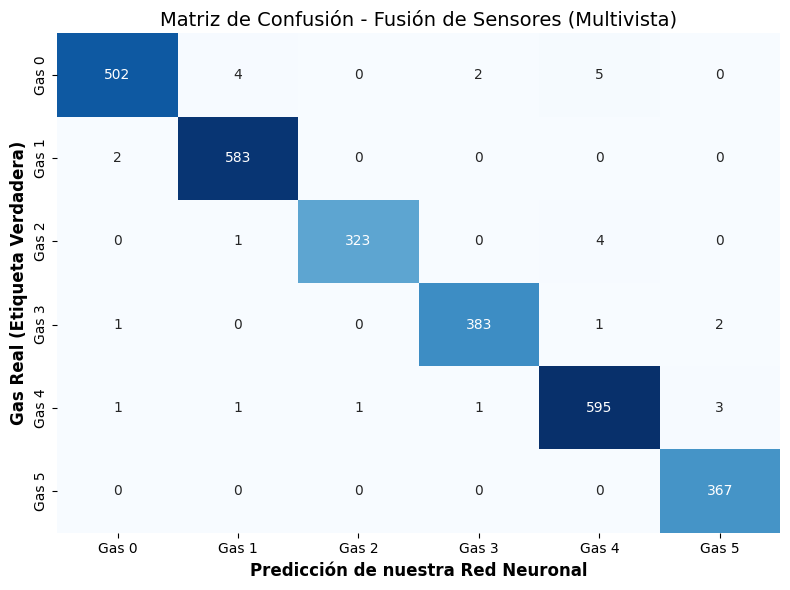

In [ ]:
print("Cargando el mejor modelo para la evaluación final...")

# 1. Instanciamos la arquitectura vacía y le cargamos los pesos de la Época 7
modelo_final = SensorFusionModel(num_classes=6).to(device)
modelo_final.load_state_dict(torch.load('mejor_modelo_gases.pt'))
modelo_final.eval() # Modo evaluación (apaga el Dropout)

# 2. Recolectar todas las predicciones y etiquetas reales del Test Set
y_verdaderas = []
y_predichas = []

with torch.no_grad(): # Sin calcular gradientes para ahorrar memoria
    for rama_A_b, rama_B_b, y_b in dataloaders['test']:
        rama_A_b, rama_B_b = rama_A_b.to(device), rama_B_b.to(device)

        # Predicción del modelo
        salidas = modelo_final(rama_A_b, rama_B_b)
        predicciones = salidas.argmax(dim=1).cpu().numpy()

        y_verdaderas.extend(y_b.cpu().numpy())
        y_predichas.extend(predicciones)

# 3. Imprimir el Reporte de Clasificación
print("\n REPORTE DE CLASIFICACIÓN:\n")
nombres_clases = [f'Gas {i}' for i in range(6)]
print(classification_report(y_verdaderas, y_predichas, target_names=nombres_clases))

# 4. Dibujar la Matriz de Confusión
cm = confusion_matrix(y_verdaderas, y_predichas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.xlabel('Predicción de nuestra Red Neuronal', fontsize=12, fontweight='bold')
plt.ylabel('Gas Real (Etiqueta Verdadera)', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Fusión de Sensores (Multivista)', fontsize=14)
plt.tight_layout()
plt.show()

**GRAFICAS DE LA CURVA DE APRENDIZAJE**

aca lo que estamos viendo es el diario de vida de nuestra inteligencia artificial durante las quince epocas de entrenamiento y es la prueba real de que el modelo funciono de maravilla en la primera grafica la de la izquierda vemos la curva de perdida que empieza super alta casi en uno punto cuatro porque al principio la red no tenia ni idea de que era cada gas pero fíjate como cae en picada rapidisimo hacia el cero eso nos dice que el optimizador hizo su trabajo perfecto ajustando las neuronas para que el error sea casi inexistente al final del proceso

en la segunda grafica la de la derecha tenemos la curva de precision que es el exito total de nuestro laboratorio porque vemos como la exactitud sube disparada desde un cincuenta por ciento hasta llegar casi al cien por ciento de efectividad lo mas importante aca es que la curva es suave y constante lo que significa que el aprendizaje fue estable y que la red no se volvio loca tratando de memorizar sino que de verdad entendio los patrones quimicos de los sensores gracias a que dividimos los datos en dos ramas para procesarlos mejor al final estas dos graficas juntas nos confirman que el modelo es super confiable y que esta listo para detectar cualquier gas con una seguridad impresionante

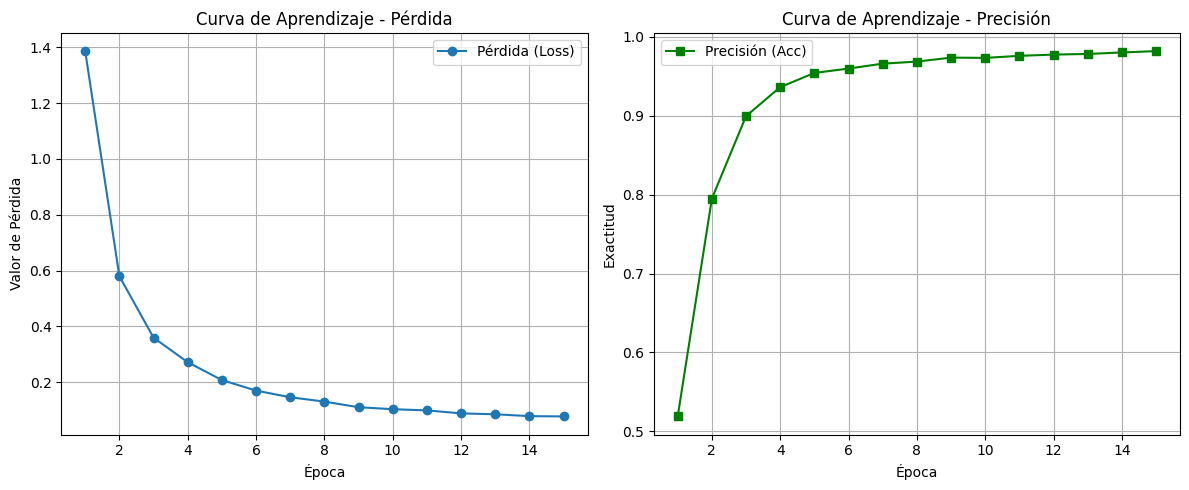

Cargando el mejor modelo...


In [ ]:
plt.figure(figsize=(12, 5))

# Gráfica de Pérdida
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history_train_loss, marker='o', label='Pérdida (Loss)')
plt.title('Curva de Aprendizaje - Pérdida')
plt.xlabel('Época')
plt.ylabel('Valor de Pérdida')
plt.legend()
plt.grid(True)

# Gráfica de Precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history_train_acc, marker='s', color='green', label='Precisión (Acc)')
plt.title('Curva de Aprendizaje - Precisión')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Cargando el mejor modelo...")